In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

In [ ]:
C_ref  = 280 # ppm
lambd = 1.75 # W/m^2/K
beta = 5.35 # W/m^2/K
c_s = 4000* 50000 # J/kg/K
c_d = 4000* 50000 # J/kg/K
kappa = 0.1 
alpha = 0.29

In [152]:
np.log(1/2)

np.float64(-0.6931471805599453)

In [163]:
def dT_s_dt(t, T_s):
    return 1/c_s * (beta * np.log(560/C_ref) - lambd * T_s)

t = np.arange(0, 100, 1) * 86400 * 365 # time in seconds

results = spi.solve_ivp(dT_s_dt, [0, t[-1]], [0], t_eval=t)

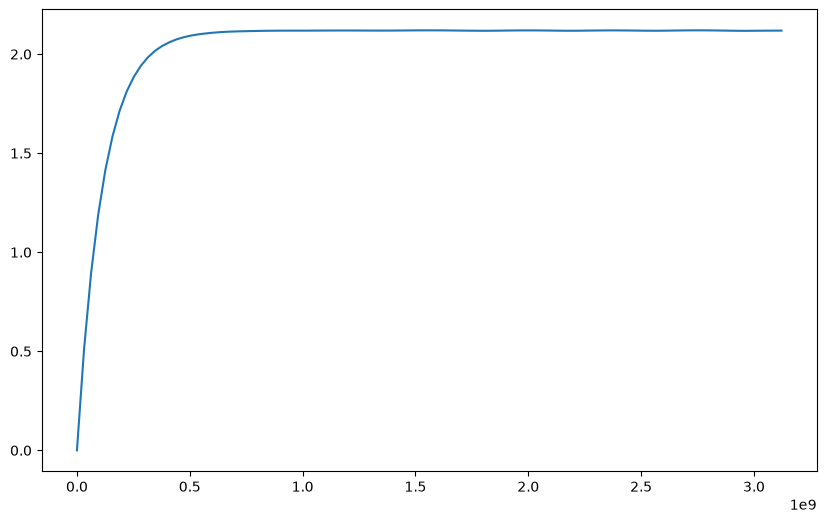

In [165]:
plt.figure(figsize=(10, 6))
plt.plot(results.t, results.y[0])

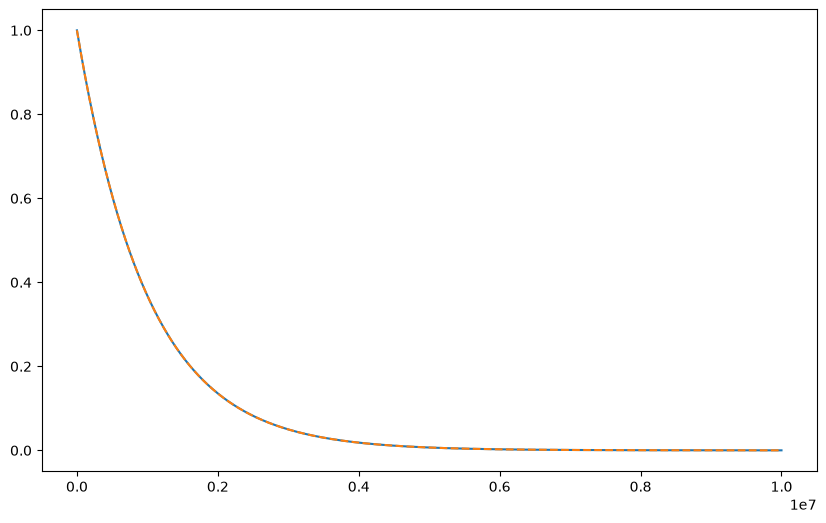

In [215]:
def dT(t, T):
    lambd = 1e-6 # 1/s
    return - lambd * T

t = np.arange(0, 10000000, 1) # time in seconds
results = spi.solve_ivp(dT, [t[0], t[-1]], [1], t_eval=t)

def T(t):
    C_0 = 1
    lambd = 1e-6 # 1/s
    return C_0 * np.exp(-lambd * t)

plt.figure(figsize=(10, 6))
plt.plot(results.t, results.y[0])
plt.plot(t, T(t), '--')

In [220]:
import numpy as np
from scipy.integrate import solve_ivp

# Parameters
cs = 4000.0 * 50 * 1000.0  # Heat capacity of the surface layer (J/m^2/K)
cd = 4000.0 * 3000.0 * 1000.0  # Heat capacity of the deep ocean layer (J/m^2/K)
lam = 1.75
etaH = 0.7
lam_star = 0.0
beta = 5.35
Ca0 = 280.0

def Ca(t):
    # Example forcing
    return 2 * 280#*np.exp(0.005*t)

def climate_rhs(t, y):
    Ts, Td = y

    forcing = beta*np.log(Ca(t)/Ca0)

    dTs = (
        -lam*Ts
        + forcing
        - (etaH + lam_star)*(Ts - Td)
    ) / cs

    dTd = etaH*(Ts - Td)/cd

    return [dTs, dTd]

y0 = [0.0, 0.0]

t = np.arange(0, 10000, 1) * 86400 * 365 # time in seconds

sol = solve_ivp(
    climate_rhs,
    (0, t[-1]),
    y0,
    method='RK45',
    t_eval=t
)

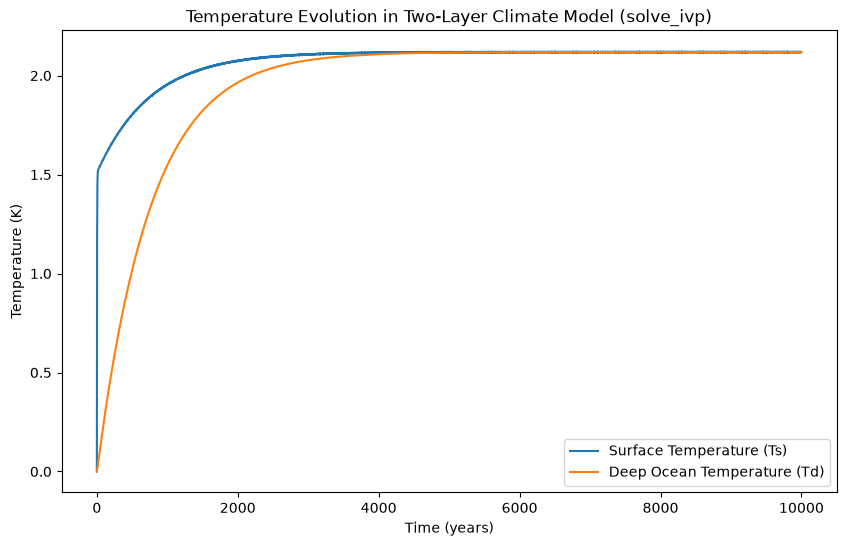

In [229]:
plt.figure(figsize=(10, 6))
plt.plot(sol.t / (86400 * 365), sol.y[0], label='Surface Temperature (Ts)')
plt.plot(sol.t / (86400 * 365), sol.y[1], label='Deep Ocean Temperature (Td)')
plt.xlabel('Time (years)')
plt.ylabel('Temperature (K)')
plt.title('Temperature Evolution in Two-Layer Climate Model (solve_ivp)')
plt.legend()

In [222]:
# Time array (seconds)
t = np.arange(0, 10000, 1) * 86400 * 365
dt = t[1] - t[0]

# Allocate solution arrays
Ts = np.zeros(len(t))
Td = np.zeros(len(t))

# Initial conditions
Ts[0] = 0.0
Td[0] = 0.0

# Time stepping
for n in range(len(t)-1):

    forcing = beta * np.log(Ca(t[n]) / Ca0)

    dTs = (
        -lam * Ts[n]
        + forcing
        - (etaH + lam_star) * (Ts[n] - Td[n])
    ) / cs

    dTd = etaH * (Ts[n] - Td[n]) / cd

    # Euler update
    Ts[n+1] = Ts[n] + dt * dTs
    Td[n+1] = Td[n] + dt * dTd

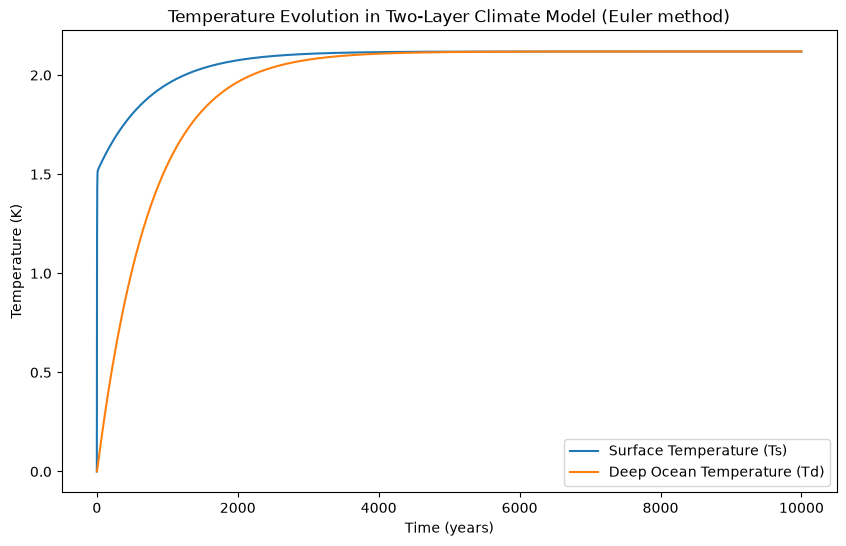

In [230]:
plt.figure(figsize=(10, 6))
plt.plot(t / (86400 * 365), Ts, label='Surface Temperature (Ts)')
plt.plot(t / (86400 * 365), Td, label='Deep Ocean Temperature (Td)')
plt.xlabel('Time (years)')
plt.ylabel('Temperature (K)')
plt.title('Temperature Evolution in Two-Layer Climate Model (Euler method)')
plt.legend()

In [235]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# -------------------------------
# Constants
# -------------------------------

h = 6.626e-34 # Planck constant (J*s)
c = 3e8 # speed of light (m/s)
kB = 1.38e-23 # Boltzmann constant (J/K)

# cloud and CO2 parameters
f_cld = 0.9
l = 10.2          # cm^-1
Tcp = 200.0       # K

# spectral window
nu1 = 800.0
nu2 = 1200.0


# ----------------------------------
# Planck function per cm^-1
# ----------------------------------

def B_wavenumber(nu_tilde_cm, T):

    # convert cm^-1 -> m^-1
    sigma = nu_tilde_cm * 100.0

    nu = c * sigma

    Bnu = (2*h*nu**3/c**2) / (np.exp(h*nu/(kB*T))-1)

    # convert from per Hz to per cm^-1
    return 100*c*Bnu


# ----------------------------------
# R(T)
# ----------------------------------

def R(T):

    integrand = lambda n: B_wavenumber(n,T)

    val,_ = quad(integrand,nu1,nu2)

    return np.pi*val


# ----------------------------------
# lambda(T)
# ----------------------------------

def lambda_T(T):

    dT = 0.01

    return (R(T+dT)-R(T-dT))/(2*dT)


# ----------------------------------
# beta(T)
# ----------------------------------

def beta(T):

    Ts = min(T,275.)

    return np.pi*2*l*f_cld*(B_wavenumber(667,Ts)-B_wavenumber(667,Tcp))

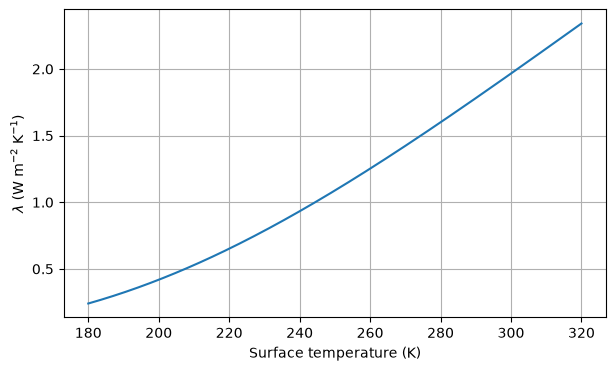

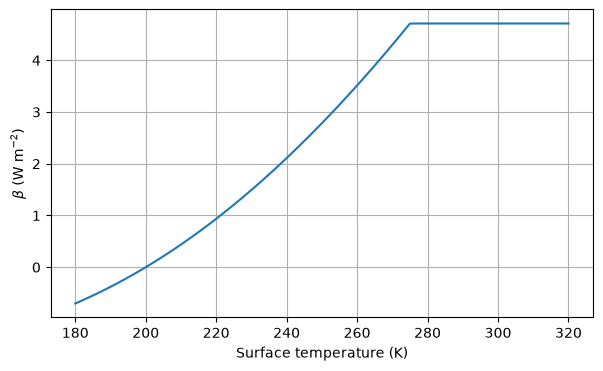

In [236]:
T = np.linspace(180,320,200)

lam = np.array([lambda_T(x) for x in T])
bet = np.array([beta(x) for x in T])

plt.figure(figsize=(7,4))
plt.plot(T,lam)
plt.xlabel("Surface temperature (K)")
plt.ylabel(r"$\lambda$ (W m$^{-2}$ K$^{-1}$)")
plt.grid()

plt.figure(figsize=(7,4))
plt.plot(T,bet)
plt.xlabel("Surface temperature (K)")
plt.ylabel(r"$\beta$ (W m$^{-2}$)")
plt.grid()

plt.show()

In [494]:
import sympy as sp
# ============================
# Parameters
# ============================

year_to_seconds = 365 * 24 * 3600
### anthropogenic emissions ###
A_tot = 5000.0   # GtC, total carbon emitted
t_opt = 250.0 * year_to_seconds    # yr, t_opt for RCP8.5

t = sp.symbols("t", real=True)

# Cumulative emissions A(t)
A = A_tot * (
    1 / (1 + 2.5 * sp.exp((t_opt - t)/year_to_seconds / 50))
    - 1 / (1 + 2.5 * sp.exp(t_opt/year_to_seconds / 50))
)

# Emission rate J(t) = dA/dt
J = sp.diff(A, t)

# Fast numerical functions
A_func = sp.lambdify(t, A, "numpy")
J_func = sp.lambdify(t, J, "numpy")

### inital Temperature ###
Ts_init = 0.0      # K, initial surface temperature
Td_init = 0.0      # K, initial deep ocean temperature
lam_star = 0.75      # W m^-2 K^-1, heat transfer coefficient
lam = 1.75         # W m^-2 K^-1, climate feedback parameter


### Heat capacities ###
surface_depth = 50.0
deep_depth = 3000.0
c_s = 4000.0 * surface_depth * 1000.0      # J m^-2 K^-1
c_d = 4000.0 * deep_depth * 1000.0       # J m^-2 K^-1
c_star = c_s + c_d                     # J m^-2 K^-1

### atmospheric carbon ###
k_a  = 2.12          # CO2 scaling constant
Ca_init = 600.0         # GtC, pre-industrial atmospheric carbon
P_a0 = Ca_init / k_a    # ppm, pre-industrial atmospheric CO2

etaH = 0.7         # W m^-2 K^-1, heat transfer coefficient

### land carbon ###
beta_pi = 0.4     # CO2 fertilization factor
chi     = 1.8     # scaling constant
tau_l0   = 41.0 * year_to_seconds    # yr, lifetime of land carbon
Pi_0    = 60.0/year_to_seconds    # GtC/yr, preindustrial land flux
Cl_init    = 2460.0  # GtC, preindustrial land carbon

### ocean carbon cycle ###
D     = surface_depth + deep_depth     # m, average ocean depth
delta = surface_depth / D    # fraction (mixed-layer depth / D)
gamma = 0.02 / year_to_seconds       # GtC/yr/ppm, air-sea transfer coefficient
mu_0  = 5.0 / year_to_seconds        # buffer constant (m/year)
zeta  = 6#10.5        # ratio between ocean reservoirs and atmosphere
etaC = mu_0/D       # transfer rate by total depth

# C_s0 + C_d0 = 6 * zeta * C_a0
# C_s0 / C_d0 = delta / (1 - delta)
# => solve the two simultaneous equations for C_s0, C_d0

total_sd = 6.0 * zeta * Ca_init   # GtC, total preindustrial ocean carbon
Cd_init = (1-delta) * total_sd   # GtC, preindustrial deep ocean carbon

Cs_init = total_sd - Cd_init               # GtC, preindustrial surface ocean carbon

kappa_o = 6.0 * k_a * delta   # ocean CO2 uptake constant


def climate_rhs(t, y):
    Ts, Td, Cl, Cs, Cd, Ca = y

    ### Anthropogenic emissions ###
    J = 0#J_func(t)  # GtC/seconds

    ### Temperature evolution surface and deep ###

    forcing = beta * np.log((Ca / Ca_init) + 1.0)

    dTs = 1.0/(delta * c_star) * (-lam*Ts + forcing - (etaH + lam_star)*(Ts - Td))

    dTd = etaH*(Ts - Td)/((1-delta)*c_star)

    # ### Land carbon evolution ###
    # ### Add question: Waht Cl to use because caligraphic Cl?

    dCl = Pi_0 * (1 + beta_pi * np.log((Ca / Ca_init) + 1.0)) - ((Cl+Cl_init) / tau_l0) * chi ** (Ts / 10.0)

    # ### Surface ocean carbon evolution ###

    ko = k_a / zeta * (Cs_init / Ca_init)

    dCs = gamma * (Ca / k_a - Cs / ko) - etaC * (Cs/delta - Cd/(1-delta))

    # ### Deep ocean carbon evolution ###

    dCd = etaC * (Cs/delta - Cd/(1-delta))

    # ### Atmosphere carbon evolution ###

    dCa = J - dCs - dCl - dCd


    return [dTs, dTd, dCl, dCs, dCd, dCa]

In [490]:
y = [Ts_init, Td_init, Cl_init, Cs_init, Cd_init, Ca_init]
y = [0,0,0,0,0,0]

In [491]:
t = np.arange(0, 10000, 1) * year_to_seconds # time in seconds

sol = solve_ivp(
    climate_rhs,
    (t[0], t[-1]),
    y,
    method='RK45',
    t_eval=t
)

In [492]:
sol['y']

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6, 10000))

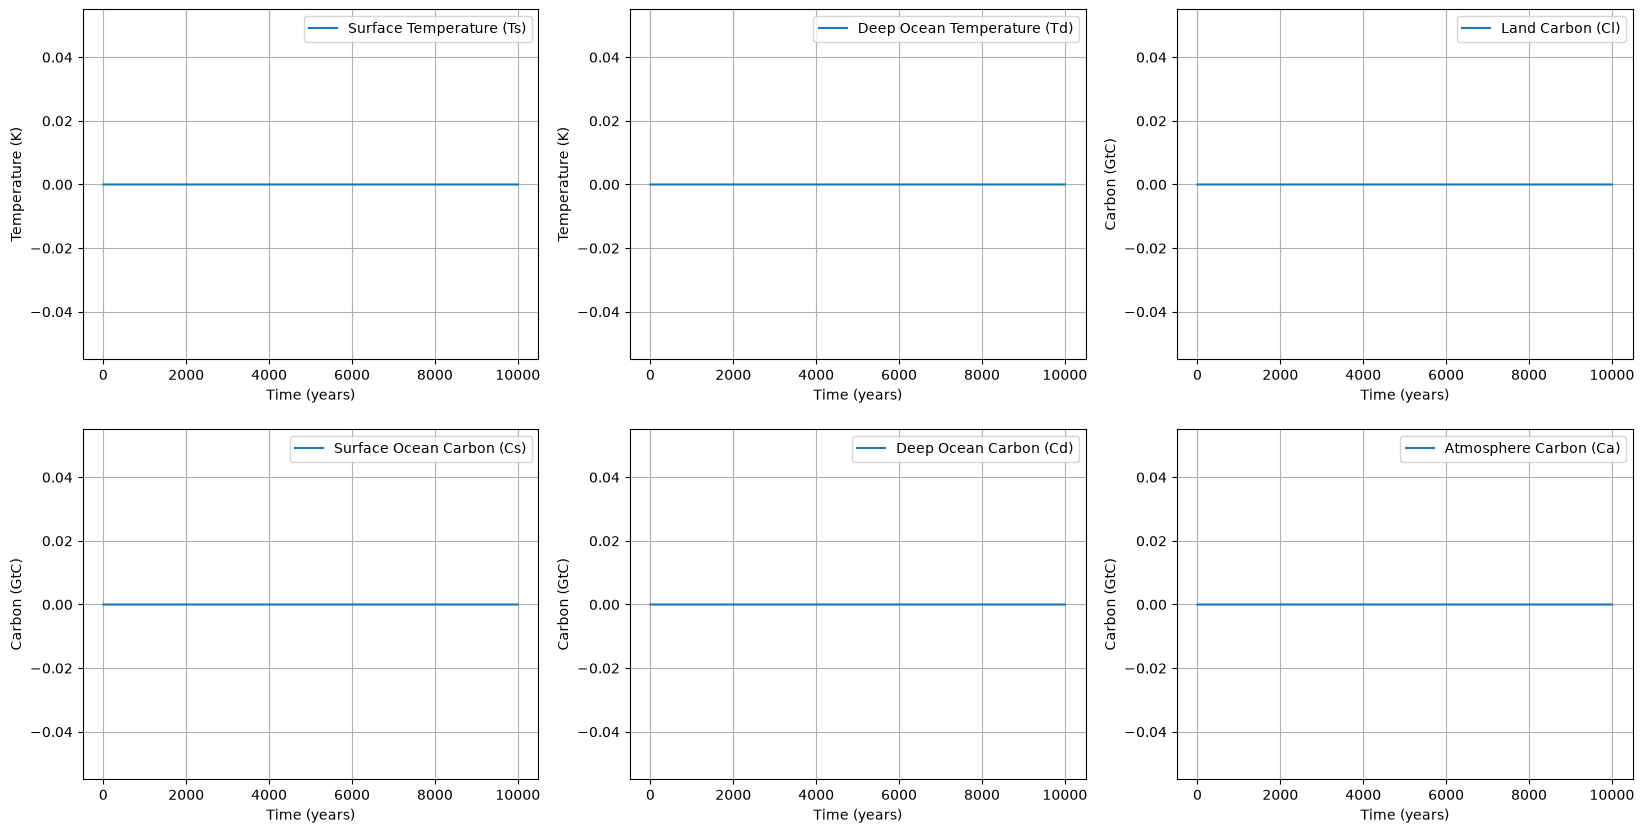

In [493]:
fig, axs = plt.subplots(2,3, figsize=(20, 10))
axs = axs.flatten()
axs[0].plot(sol.t / (86400 * 365), sol.y[0], label='Surface Temperature (Ts)')
axs[0].set_xlabel('Time (years)')
axs[0].set_ylabel('Temperature (K)')
axs[1].plot(sol.t / (86400 * 365), sol.y[1], label='Deep Ocean Temperature (Td)')
axs[1].set_xlabel('Time (years)')
axs[1].set_ylabel('Temperature (K)')
axs[2].plot(sol.t / (86400 * 365), sol.y[2], label='Land Carbon (Cl)')
axs[2].set_xlabel('Time (years)')
axs[2].set_ylabel('Carbon (GtC)')
axs[3].plot(sol.t / (86400 * 365), sol.y[3], label='Surface Ocean Carbon (Cs)')
axs[3].set_xlabel('Time (years)')
axs[3].set_ylabel('Carbon (GtC)')
axs[4].plot(sol.t / (86400 * 365), sol.y[4], label='Deep Ocean Carbon (Cd)')
axs[4].set_xlabel('Time (years)')
axs[4].set_ylabel('Carbon (GtC)')
axs[5].plot(sol.t / (86400 * 365), sol.y[5], label='Atmosphere Carbon (Ca)')
axs[5].set_xlabel('Time (years)')
axs[5].set_ylabel('Carbon (GtC)')

for ax in axs:
    ax.grid()
    ax.legend()



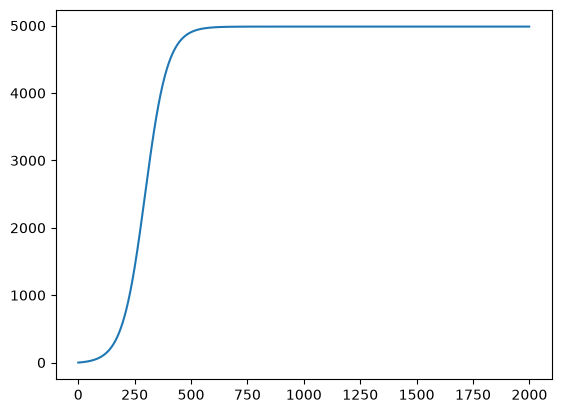

In [439]:
plt.plot(t/year_to_seconds, A_func(t))